In [13]:
from pathlib import Path
import csv
import importlib

import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

import utils
from dataset import get_celeba_loader

importlib.reload(utils)
from utils import MetricLogger, plot_training_metrics,plot_ablation_cards

import os
import pandas as pd


In [2]:
# Dataloader logic aligned with train.py
subset_size = 20_000
batch_size = 64
data_path = "./data/celeba"

loader = get_celeba_loader(
    subset_size=subset_size,
    batch_size=batch_size,
    data_path=data_path,
)

print(f"Loaded {len(loader)} batches from {data_path}")

Loaded 313 batches from ./data/celeba


[Plot] Training metrics saved -> outputs/training_metrics.png
Plot saved to: /home/crisp/Projects/ddgm/outputs/training_metrics.png


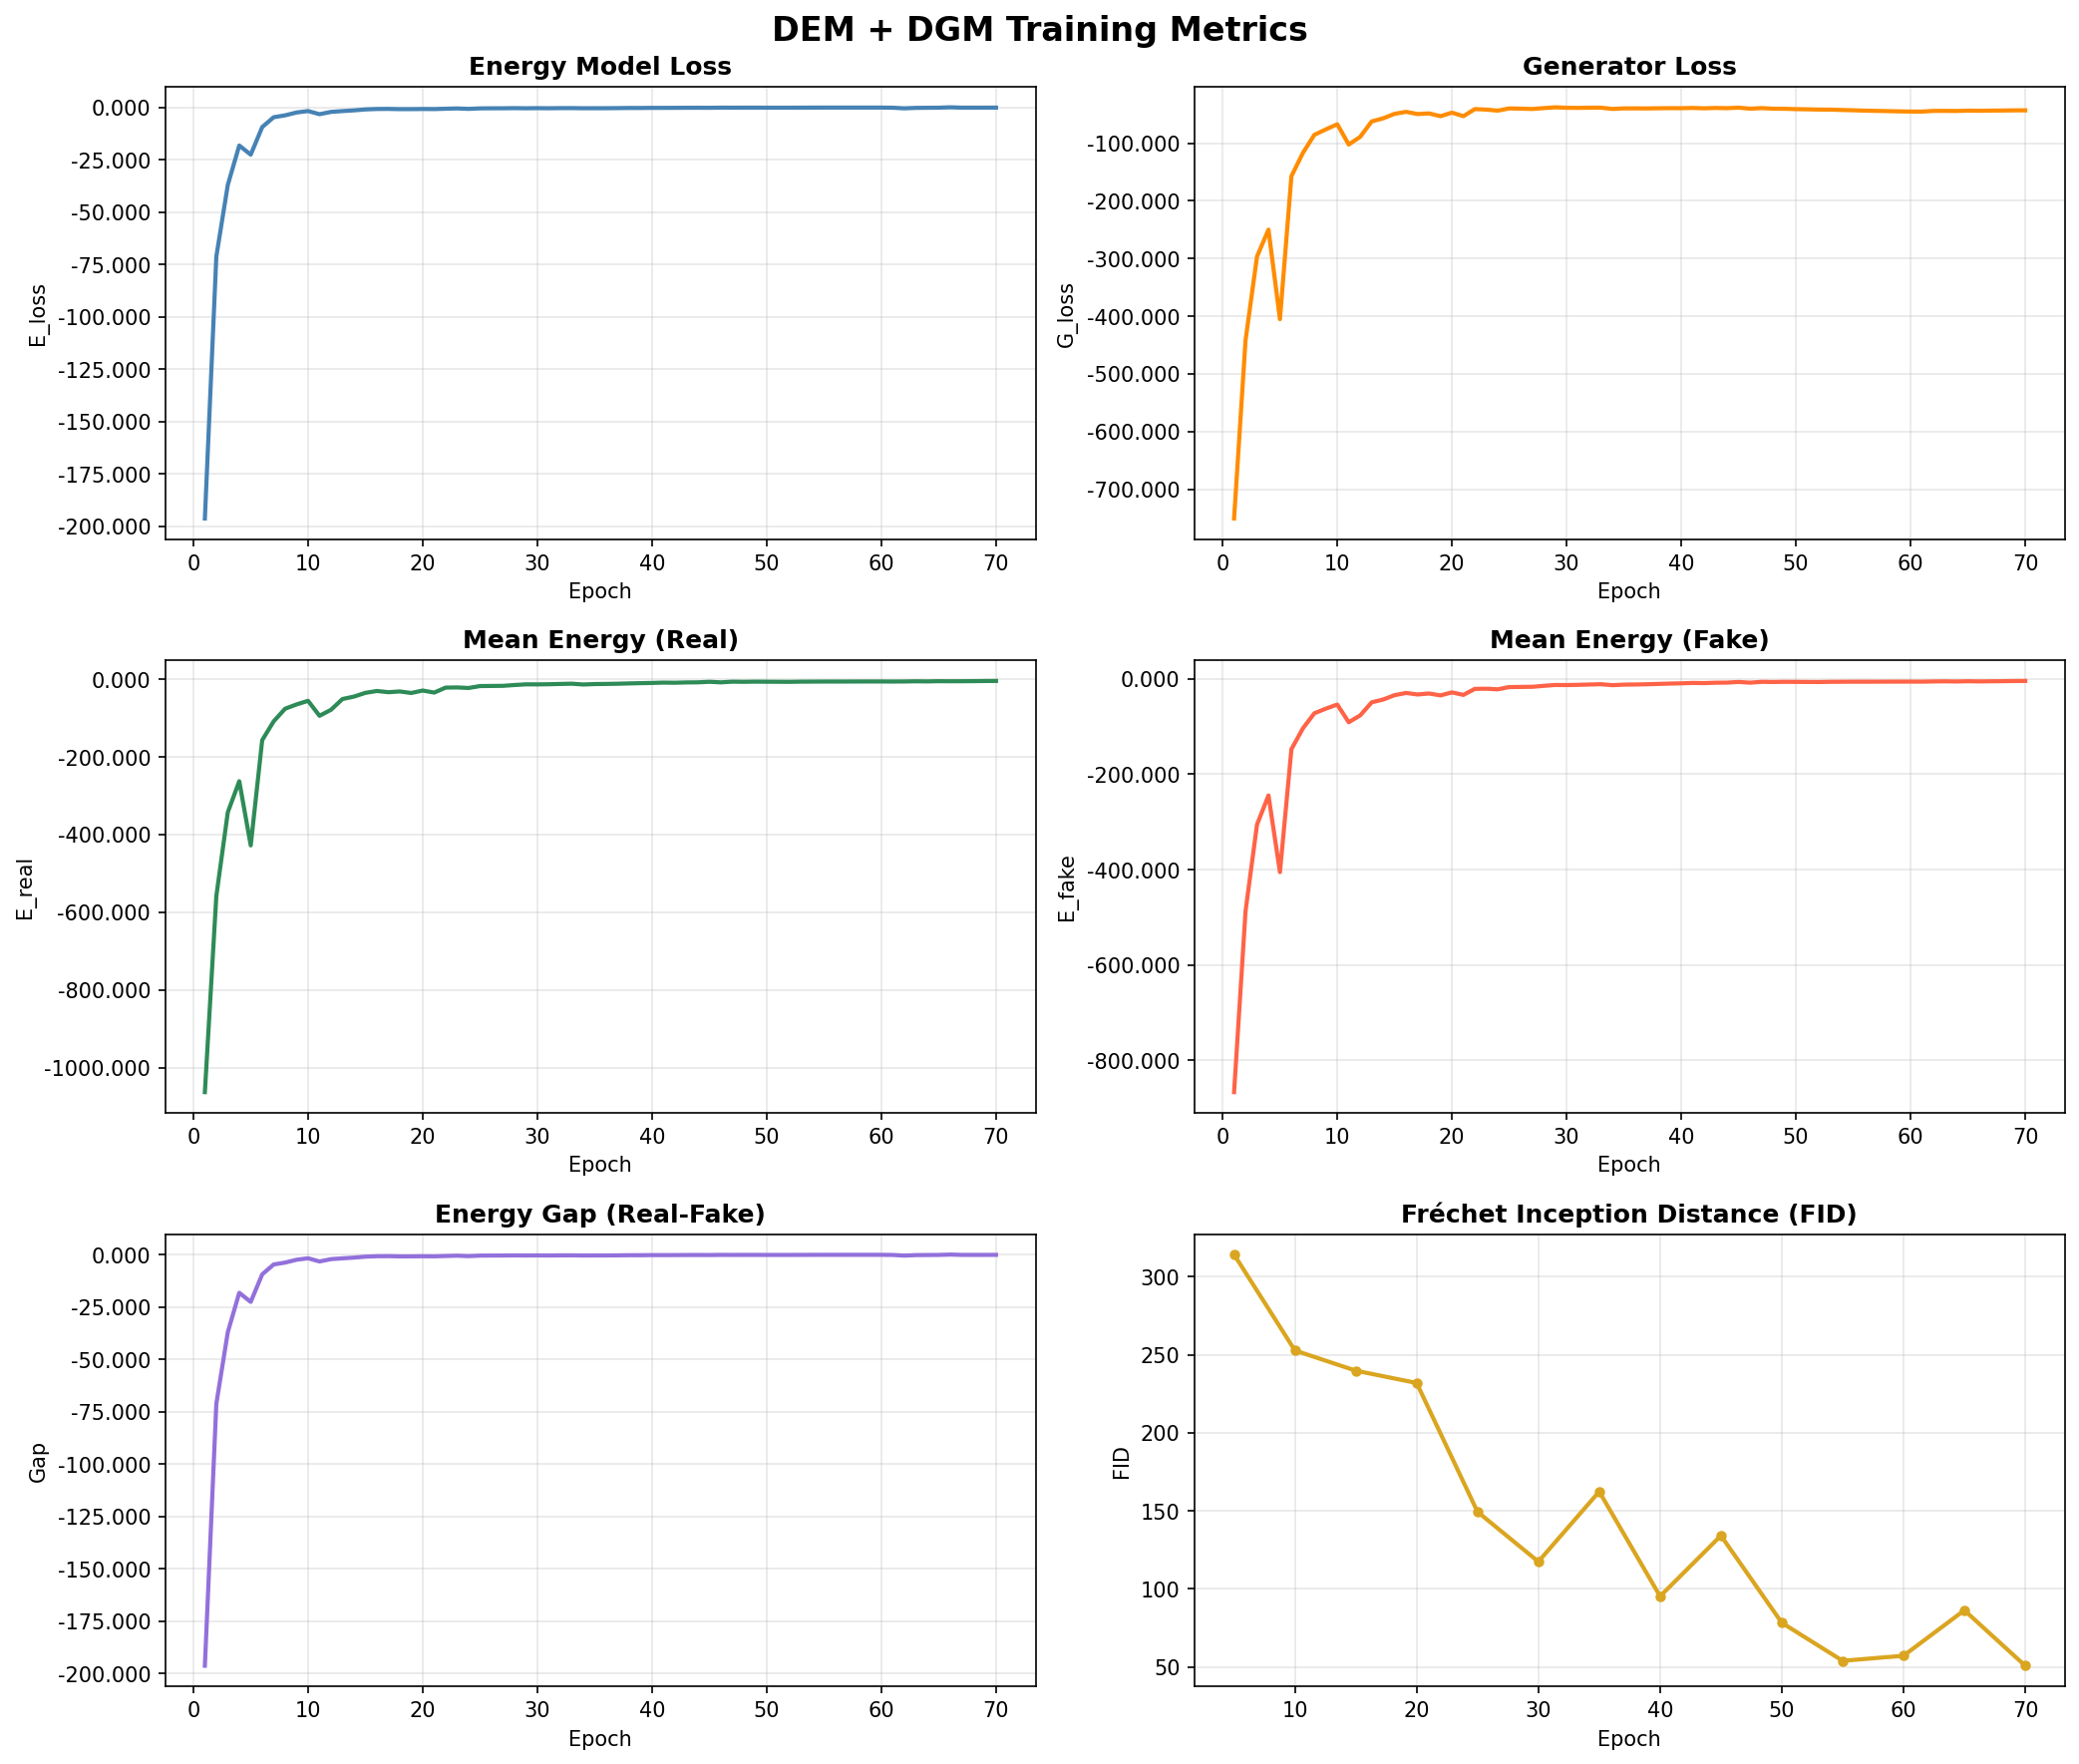

In [3]:
# Load CSV metrics into a logger-like object, plot, and show the generated image
metrics_csv = Path("./outputs/outputs_base/metrics.csv")
output_dir = Path("./outputs")

if not metrics_csv.exists():
    raise FileNotFoundError(f"Metrics CSV not found: {metrics_csv.resolve()}")

# Use a temporary logger path so we don't overwrite the real metrics.csv
tmp_logger_path = output_dir / "_tmp_notebook_logger.csv"
logger = MetricLogger(str(tmp_logger_path))
logger.records = []

with open(metrics_csv, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        logger.records.append(row)

plot_training_metrics(logger, str(output_dir))
plot_path = output_dir / "training_metrics.png"

print(f"Plot saved to: {plot_path.resolve()}")
display(Image(filename=str(plot_path)))

In [17]:
from pathlib import Path
import importlib
import utils

importlib.reload(utils)

base_config_path = Path("./config/base.yaml")
base_cfg = utils.load_base_config(base_config_path)

print(f"Loaded base config from: {base_config_path.resolve()}")
print(f"Config keys: {len(base_cfg)}")

Loaded base config from: /home/crisp/Projects/ddgm/config/base.yaml
Config keys: 34


In [5]:
experiments = {
    "run_1_baseline": {}, 
    "run_2_dem_nerf": {
        "lr_e": 5e-5,
        "clip_grad_e": 1.0
    },
    "run_3_g_boost": {
        "n_gen_steps": 2
    },
    "run_4_strict_penalty": {
        "r1_every": 2
    },
    "run_5_hard_bound": {
        "margin": 20.0
    },
    "run_6_balanced": {
        "lr_e": 5e-5,
        "n_gen_steps": 2
    }
}

In [ ]:
from copy import deepcopy
from pathlib import Path
import csv
import gc

import torch
from train import train

common_overrides = {
    "epochs": 30,
    "fid_every": 3,
    "sample_every": 5,
    "save_checkpoint_every": 10**9,
    "resume": None,
}

ablation_rows = []

for exp_name, exp_overrides in experiments.items():
    cfg = deepcopy(base_cfg)
    cfg.update(common_overrides)
    cfg.update(exp_overrides)
    cfg["output_dir"] = f"./outputs/{exp_name}/"

    print(f"Doing {exp_name}")

    # Silence verbose training logs; keep notebook output concise.
    train(cfg)

    exp_metrics_path = Path(cfg["output_dir"]) / "metrics.csv"
    if not exp_metrics_path.exists():
        print(f"[WARN] Metrics not found for {exp_name}: {exp_metrics_path}")
        continue

    with open(exp_metrics_path, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))

    if not rows:
        print(f"[WARN] Empty metrics file for {exp_name}: {exp_metrics_path}")
        continue

    final_row = dict(rows[-1])
    final_row["exp_name"] = exp_name
    final_row["output_dir"] = cfg["output_dir"]
    ablation_rows.append(final_row)

    # Explicit cleanup between experiments.
    del cfg
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Write consolidated ablation table to project root
ablation_table_path = Path("./metrics.csv")
if ablation_rows:
    fieldnames = ["exp_name", "output_dir"] + [
        k for k in ablation_rows[0].keys() if k not in {"exp_name", "output_dir"}
    ]
    with open(ablation_table_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(ablation_rows)

    print(f"Saved ablation table: {ablation_table_path.resolve()}")
else:
    print("No ablation rows were collected; metrics.csv was not written.")


Doing run_1_baseline


Epoch: 1 done


Epoch: 2 done


  [FID] Loading InceptionV3 on CPU...
  [FID] Collecting 2000 real features...
  [FID] Generating 2000 fake features...
  [FID] = 310.25
Epoch: 3 done


Epoch: 4 done


...

  [FID] Generating 2000 fake features...
  [FID] = 277.07
Epoch: 27 done


Epoch: 28 done


Epoch: 29 done


  [FID] Collecting 2000 real features...


  [FID] Generating 2000 fake features...
  [FID] = 202.41
  [Samples] Saved 64 images -> outputs/run_6_balanced/samples/epoch_0030.png
Epoch: 30 done

[Training complete] Saving final samples and metrics plot...
  [Samples] Saved 64 images -> outputs/run_6_balanced/samples/epoch_0030.png
[Plot] Training metrics saved -> outputs/run_6_balanced/training_metrics.png

All outputs saved to: /home/crisp/Projects/ddgm/outputs/run_6_balanced
Saved ablation table: /home/crisp/Projects/ddgm/metrics.csv


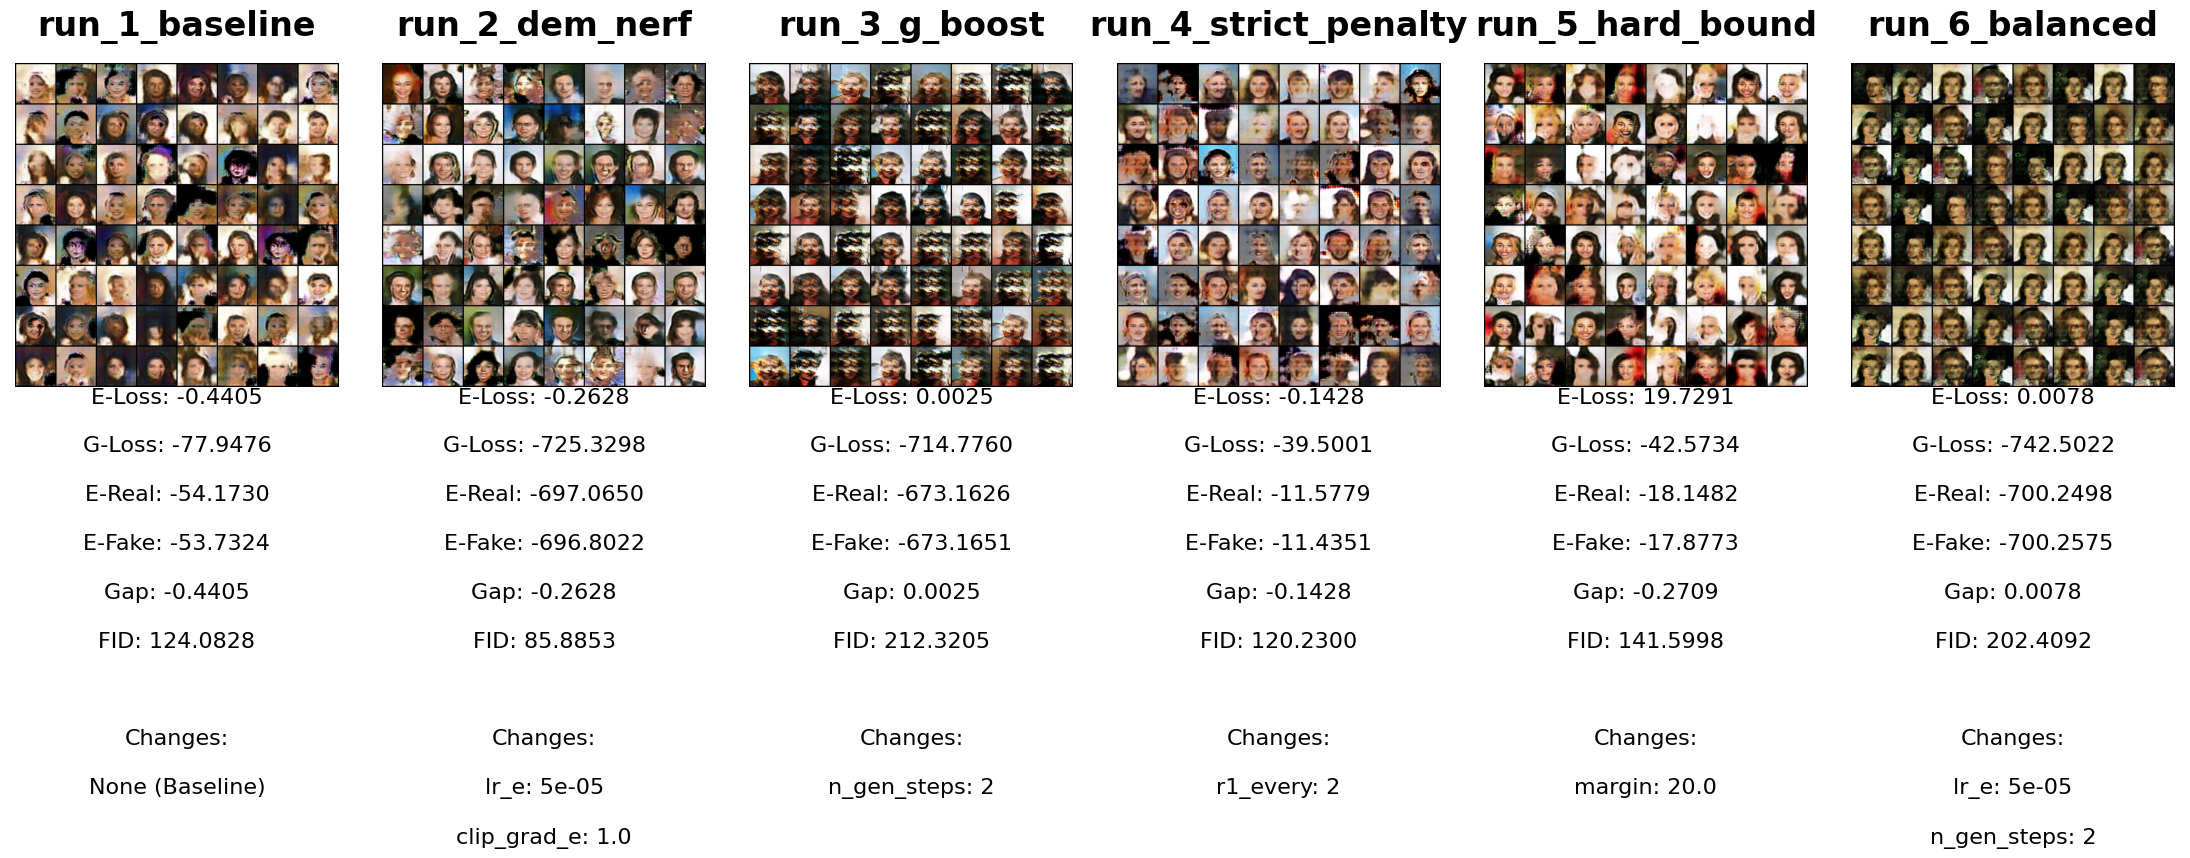

In [14]:
df = pd.read_csv("metrics.csv")
plot_ablation_cards(df,params_dict=experiments)

In [6]:
from pathlib import Path
import importlib

import torch
import utils
import train as train_module

# Reload modules so notebook uses latest train.py and utils.py changes.
importlib.reload(utils)
train_module = importlib.reload(train_module)

final_config_path = Path("./config/final.yaml")
final_cfg = utils.load_base_config(final_config_path)

# Ensure run targets CUDA when available.
if torch.cuda.is_available() and final_cfg.get("device", "auto") == "cpu":
    final_cfg["device"] = "auto"

print(f"Loaded final config from: {final_config_path.resolve()}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Configured device: {final_cfg.get('device')}")

# Run final training with reloaded train module (includes GPU FID path).
train_module.train(final_cfg)


Loaded final config from: /home/crisp/Projects/ddgm/config/final.yaml
CUDA available: True
Configured device: cuda


Epoch: 1 done


Epoch: 2 done


Epoch: 3 done


Epoch: 4 done


...

Epoch: 197 done


Epoch: 198 done


Epoch: 199 done


  [FID] Collecting 2000 real features...


  [FID] Generating 2000 fake features...
  [FID] = 25.12
  [PR ] precision=0.871 recall=0.661
  [Samples] Saved 64 images -> outputs/final/samples/epoch_0200.png
[Checkpoint] Saved -> outputs/final/checkpoints/ckpt_epoch_0200.pt
Epoch: 200 done

[Training complete] Saving final samples and metrics plot...
  [Samples] Saved 64 images -> outputs/final/samples/epoch_0200.png
[Plot] Training metrics saved -> outputs/final/training_metrics.png

All outputs saved to: /home/crisp/Projects/ddgm/outputs/final


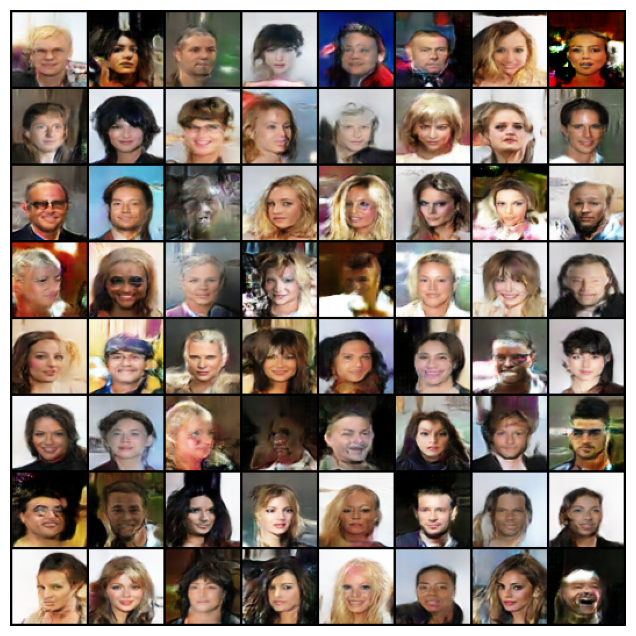

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from models_generator import DeepGenerativeModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 512
feature_dim = 512

model = DeepGenerativeModel(
    latent_dim=latent_dim,
    n_features=feature_dim
).to(device)

ckpt = torch.load("outputs/final/checkpoints/latest.pt", map_location=device)
model.load_state_dict(ckpt["dgm"])
model.eval()

with torch.no_grad():
    imgs = model.generate(64, device).cpu()

grid = make_grid((imgs + 1) / 2, nrow=8)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0))
plt.show()